In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob
import sklearn as sk
# D -> A

d:\conda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\conda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
data_path = r"..\data\data_2358.csv" if os.name == "nt" else "../data/data_2358.csv"

if not os.path.exists(data_path):
    matches = glob.glob("**/data_2358.csv", recursive=True)
    if matches:
        data_path = matches[0]
    else:
        for root, _, files in os.walk("."):
            if "data_2358.csv" in files:
                data_path = os.path.join(root, "data_2358.csv")
                break

if not os.path.exists(data_path):
    raise FileNotFoundError(
        "data_2358.csv not found. Place the file in the notebook directory or specify the correct path."
    )

df = pd.read_csv(data_path)
print(f"Loaded data from: {data_path}")
df = df.iloc[:, 1:]  # Behold alt fra kolonne 1 og fremefter

Loaded data from: ..\data\data_2358.csv


In [3]:
data_path_int_nega = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
data_path_int_posa = r"..\data\2a.csv" if os.name == "nt" else "../data/2a.csv"

df_int_nega = pd.read_csv(data_path_int_nega)
df_int_posa = pd.read_csv(data_path_int_posa)
df_int_nega = df_int_nega.iloc[:, 1:]  # Behold alt fra kolonne 1 og fremefter
df_int_posa = df_int_posa.iloc[:, 1:]  

def normalize_columns(df):
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()
    return df
data_path_int_negab = r"..\data\-2b.csv" if os.name == "nt" else "../data/-2b.csv"
data_path_int_posc = r"..\data\2c.csv" if os.name == "nt" else "../data/2c.csv"
data_path_int_posd = r"..\data\2d.csv" if os.name == "nt" else "../data/2d.csv"
data_path_int_pose = r"..\data\2e.csv" if os.name == "nt" else "../data/2e.csv"
data_path_int_negf = r"..\data\-2f.csv" if os.name == "nt" else "../data/-2f.csv"
data_path_int_nuld = r"..\data\0d.csv" if os.name == "nt" else "../data/0d.csv"
data_path_int_nulb = r"..\data\0b.csv" if os.name == "nt" else "../data/0b.csv"
data_path_int_nulec = r"..\data\0ec.csv" if os.name == "nt" else "../data/0ec.csv"

df_int_negb = pd.read_csv(data_path_int_negab)
df_int_posc = pd.read_csv(data_path_int_posc)
df_int_posd = pd.read_csv(data_path_int_posd)
df_int_pose = pd.read_csv(data_path_int_pose)
df_int_negf = pd.read_csv(data_path_int_negf)
df_int_nuld = pd.read_csv(data_path_int_nuld)
df_int_nulb = pd.read_csv(data_path_int_nulb)
df_int_nulec = pd.read_csv(data_path_int_nulec)

df_int_negb = df_int_negb.iloc[:, 1:]  
df_int_posc = df_int_posc.iloc[:, 1:]  
df_int_posd = df_int_posd.iloc[:, 1:]  
df_int_pose = df_int_pose.iloc[:, 1:] 
df_int_negf = df_int_negf.iloc[:, 1:]  
df_int_nuld = df_int_nuld.iloc[:, 1:]  
df_int_nulb = df_int_nulb.iloc[:, 1:]  
df_int_nulec = df_int_nulec.iloc[:, 1:]  

df_rand = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_rand = df_rand.iloc[0:30 ,: ]  
df_int_nulec_rand = df_int_nulec.sample(frac=1, random_state=42).reset_index(drop=True)
df_int_nulec_rand = df_int_nulec_rand.iloc[0:30 ,: ]  


In [148]:
from pathlib import Path


def calculate_points(data, guesses: int) -> int:
    """Beregn point ud fra antal gæt og antal rækker i hver datafil.

    Regler:
    - hvert gæt giver 70 point
    - hver datafil i mappen giver 20 point + antal rows i filen

    Parametre:
    data:
        Sti til data-mappen eller en iterable af DataFrames.
    guesses (int): Antal gæt.
    """
    points = guesses * 70

    # Hvis data er en mappe, gennemgå alle CSV-filer i mappen
    if isinstance(data, (str, Path)):
        data_path = Path(data)
        if not data_path.exists():
            raise FileNotFoundError(f"Data path not found: {data_path}")

        for file_path in data_path.rglob("*.csv"):
            df_file = pd.read_csv(file_path)
            points += 20 + len(df_file)

    # Hvis data er en liste/iterabel af DataFrames
    else:
        for df_item in data:
            points += 20 + len(df_item)

    return points

points = calculate_points(r"..\data", guesses=20)
print(points)


2470


In [91]:
def MeanVariance(df):
    mean = df.mean()
    variance = df.var()
    return mean, variance
mean, variance = MeanVariance(df)
print("Mean:\n", mean)
print("\nVariance:\n", variance)
Mean, Variance = MeanVariance(df_int_nulec)
print("\nIntervention Data:")
print("Mean:\n", Mean)
print("\nVariance:\n", Variance)

print (f"difference between means: {mean - Mean}")
print (f"difference between variances: {variance - Variance}")

Mean:
 A    6.991572
B    4.140744
C   -0.130260
D   -1.128586
E   -1.149833
F    1.066195
dtype: float64

Variance:
 A    98.086601
B    27.103203
C     2.179402
D     5.260365
E     1.280953
F     3.503626
dtype: float64

Intervention Data:
Mean:
 A    8.543259
B    4.094055
C    0.000000
D   -1.080405
E    0.000000
F    0.039309
dtype: float64

Variance:
 A    279.328245
B     25.747015
C      0.000000
D      6.660118
E      0.000000
F      0.053702
dtype: float64
difference between means: A   -1.551687
B    0.046689
C   -0.130260
D   -0.048180
E   -1.149833
F    1.026886
dtype: float64
difference between variances: A   -181.241644
B      1.356188
C      2.179402
D     -1.399753
E      1.280953
F      3.449924
dtype: float64


In [65]:
def stat_test_non_parametric(df1, df2, var):
    from scipy.stats import mannwhitneyu
    stat, p = mannwhitneyu(df1[var], df2[var])
    print(f"Non-parametric test for {var}: U={stat:.4f}, p-value={p:.4f}")

for i in range(len(df.select_dtypes(include=np.number).columns)):
    var = df.select_dtypes(include=np.number).columns[i]
    stat_test_non_parametric(df, df_int_posc, var)

Non-parametric test for A: U=1820.0000, p-value=0.0775
Non-parametric test for B: U=1545.0000, p-value=0.8058
Non-parametric test for C: U=150.0000, p-value=0.0000
Non-parametric test for D: U=1467.0000, p-value=0.8575
Non-parametric test for E: U=1364.0000, p-value=0.4540
Non-parametric test for F: U=390.0000, p-value=0.0000


In [97]:
def paired_ttest(df1, df2, var):
    from scipy.stats import ttest_rel
    stat, p = ttest_rel(df1[var], df2[var])
    print(f"Paired t-test for {var}: t={stat:.4f}, p-value={p:.9f}")

for i in range(len(df.select_dtypes(include=np.number).columns)):
    var = df.select_dtypes(include=np.number).columns[i]
    paired_ttest(df_rand, df_int_posd, var)

Paired t-test for A: t=1.6721, p-value=0.105269115
Paired t-test for B: t=-0.2619, p-value=0.795276628
Paired t-test for C: t=-2.5022, p-value=0.018232691
Paired t-test for D: t=-5.9230, p-value=0.000001968
Paired t-test for E: t=-0.5321, p-value=0.598716056
Paired t-test for F: t=-1.0463, p-value=0.304065284


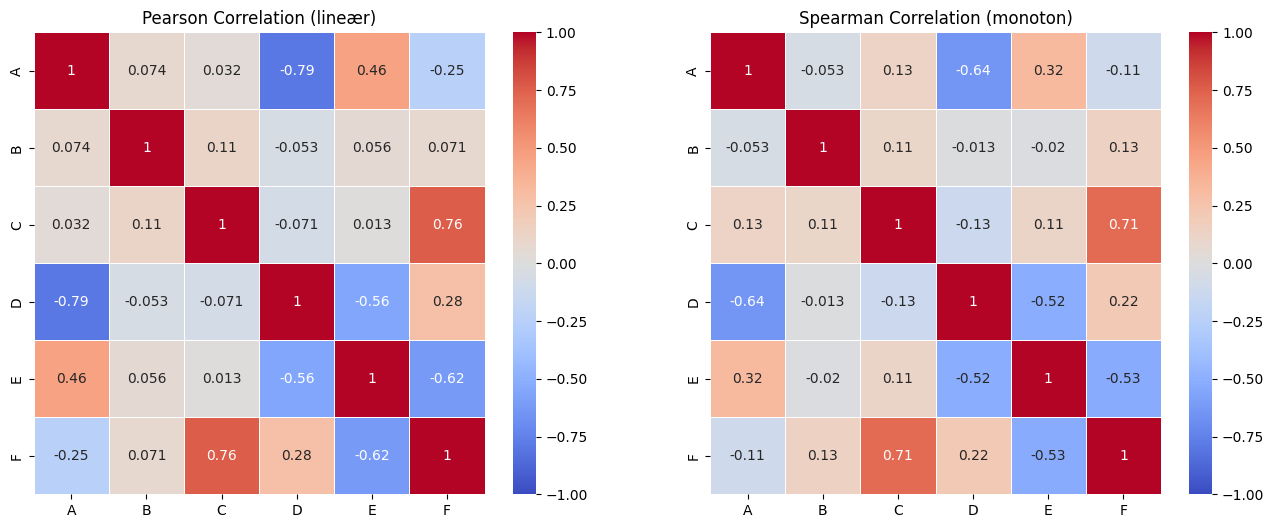

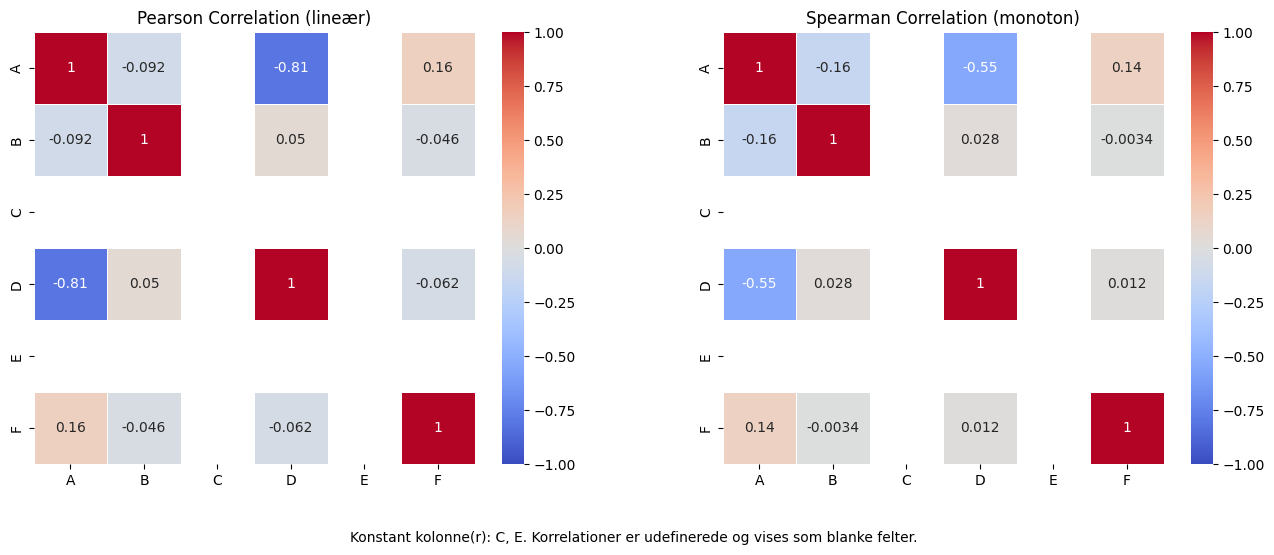

In [92]:
def compare_correlations(df, reference_columns=None):
    """Plot Pearson and Spearman correlations side by side"""
    numeric_df = df.select_dtypes(include=np.number).copy()
    if reference_columns is None:
        reference_columns = numeric_df.columns.tolist()
    pearson_corr = numeric_df.corr(method='pearson').reindex(index=reference_columns, columns=reference_columns)
    spearman_corr = numeric_df.corr(method='spearman').reindex(index=reference_columns, columns=reference_columns)
    constant_columns = [col for col in reference_columns if numeric_df[col].nunique(dropna=True) <= 1 if col in numeric_df.columns]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pearson
    sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title("Pearson Correlation (lineær)", fontsize=12)
    
    # Spearman
    sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title("Spearman Correlation (monoton)", fontsize=12)
    if constant_columns:
        fig.subplots_adjust(bottom=0.16, wspace=0.25)
        fig.text(0.5, 0.03, f"Konstant kolonne(r): {', '.join(constant_columns)}. Korrelationer er udefinerede og vises som blanke felter.", ha='center', fontsize=10)
    
    plt.show()

common_columns = df.select_dtypes(include=np.number).columns.tolist()
compare_correlations(df, reference_columns=common_columns)
compare_correlations(df_int_nulec, reference_columns=common_columns)

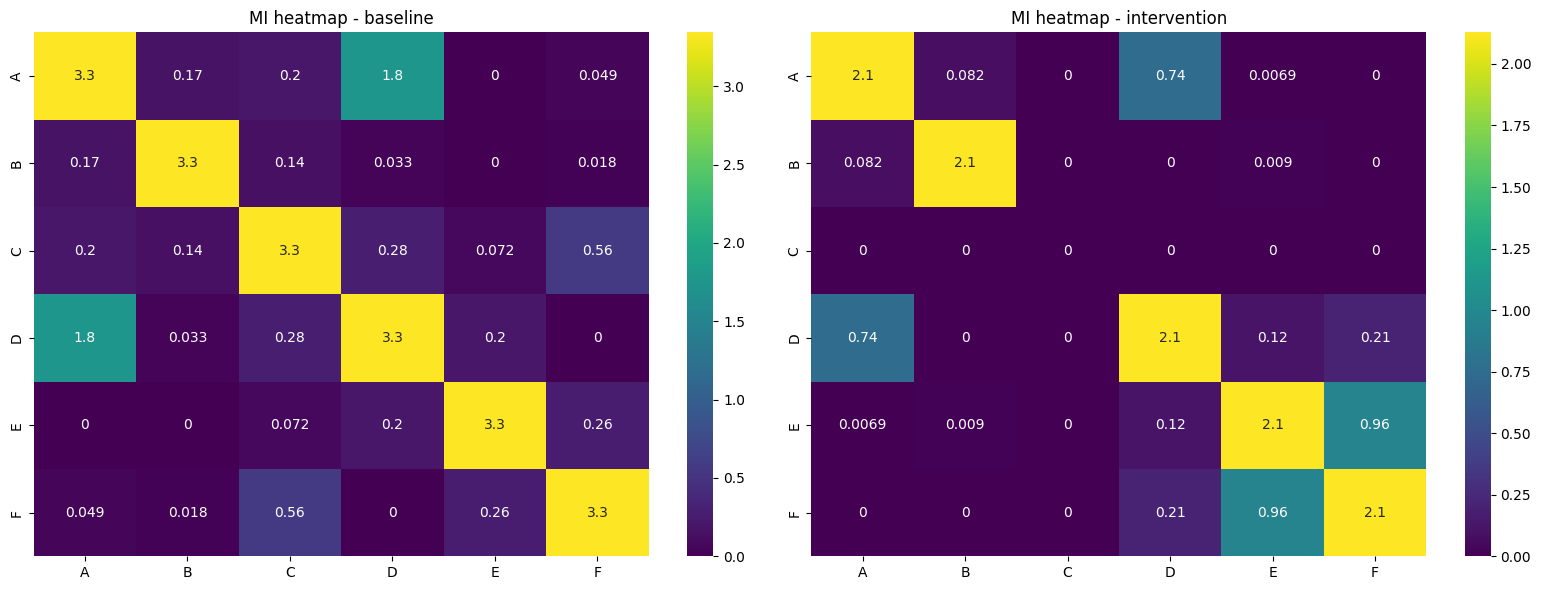

In [141]:
from sklearn.feature_selection import mutual_info_regression

def calculate_mi_matrix(df):
    variables = df.columns
    mi_matrix = pd.DataFrame(index=variables, columns=variables)
    
    for i in variables:
        for j in variables:
            # Vi beregner MI mellem variabel i og j
            # Reshape er nødvendig for sklearn
            mi = mutual_info_regression(df[[i]], df[j], random_state=42)
            mi_matrix.loc[i, j] = mi[0]
            
    return mi_matrix.astype(float)

# Kør den på jeres baseline data
mi_results = calculate_mi_matrix(df)
mi_int_results = calculate_mi_matrix(df_int_posc)  # Behold alt


common_columns = df.columns.tolist()
mi_results = mi_results.reindex(index=common_columns, columns=common_columns)
mi_int_results = mi_int_results.reindex(index=common_columns, columns=common_columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(mi_results, annot=True, cmap="viridis", ax=axes[0])
axes[0].set_title("MI heatmap - baseline")
sns.heatmap(mi_int_results, annot=True, cmap="viridis", ax=axes[1])
axes[1].set_title("MI heatmap - intervention")
plt.tight_layout()
plt.show()

In [24]:
# Beregn ACE (Average Causal Effect) for at se om A flytter E
ace_a_to_e = (df_int_posa_norm['E'].mean() - df_int_nega_norm['E'].mean()) / 4
print(f"ACE A -> E: {ace_a_to_e}")

# Hvis ACE er tæt på 0, men MI(D,E) er høj, så er forbindelsen D-E skabt af H!

ACE A -> E: 7.271960811294776e-17


Loaded intervention data from: ..\data\-2a.csv


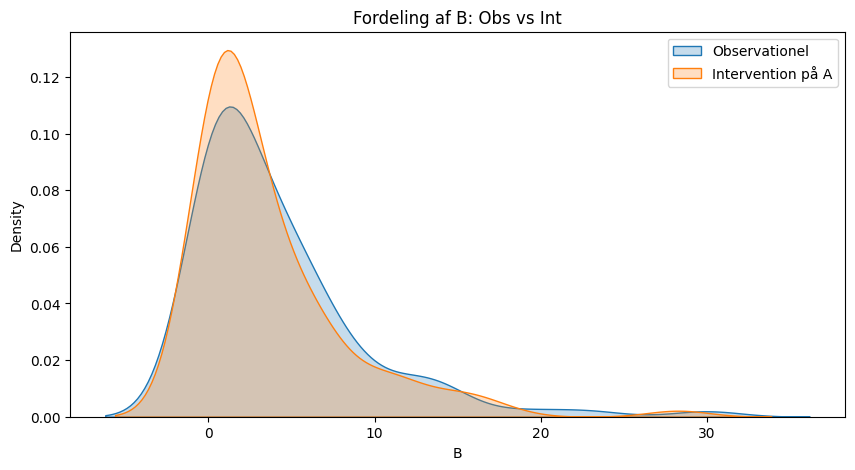

In [140]:
def check_confounder(obs_df, int_df_a, var_target='B'):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(obs_df[var_target], label='Observationel', fill=True)
    sns.kdeplot(int_df_a[var_target], label=f'Intervention på A', fill=True)
    plt.legend()
    plt.title(f"Fordeling af {var_target}: Obs vs Int")
    plt.show()

data_path_int = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
df_int = pd.read_csv(data_path_int)
print(f"Loaded intervention data from: {data_path_int}")


check_confounder(df, df_int_nuld, var_target='B')

In [32]:
def estimate_ace(df_high, df_low, target_var):
    """
    Estimate the Average Causal Effect (ACE) of a treatment variable on a target variable.
    
    Parameters:
    df_high (pd.DataFrame): DataFrame with high treatment values
    df_low (pd.DataFrame): DataFrame with low treatment values
    target_var (str): Name of the target variable
    # Average Causal Effect (ACE) estimation

    # ACE > 0: X har en positiv effekt på Y (X op -> Y op).
    # ACE < 0: X har en negativ effekt på Y (X op -> Y ned).
    # ACE = 0: X har ingen kausal effekt på Y 
    
    Returns:
    float: The estimated ACE
    """     
    # E[Y | do(X=2)] - E[Y | do(X=-2)] divideret med afstanden i X (4)
    ace = (df_high[target_var].mean() - df_low[target_var].mean()) / 4
    return ace

data_path_high = r"..\data\2a.csv" if os.name == "nt" else "../data/2a.csv"
data_path_low = r"..\data\-2a.csv" if os.name == "nt" else "../data/-2a.csv"
df_high = df_int_posa

df_low = df_int_nega

targets = [c for c in df_high.select_dtypes(include=np.number).columns if c != 'A' and not str(c).startswith('Unnamed')]
ace_results = {}
for t in targets:
    ace_results[t] = estimate_ace(df_high, df_low, target_var=t)

# keep ace_estimate for compatibility with the existing print
ace_estimate = ace_results.get('C', next(iter(ace_results.values())) if ace_results else np.nan)

for t, v in ace_results.items():
    print(f"Estimated ACE of A on {t}: {v:.3f}")

Estimated ACE of A on B: 0.188
Estimated ACE of A on C: 0.002
Estimated ACE of A on D: 0.017
Estimated ACE of A on E: -0.000
Estimated ACE of A on F: -0.012


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


def estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols=None, random_state=42):
    """
    Estimerer en kausal effekt med en hybrid/double-machine-learning stil:
    - fleksibel model til at fange lineære og ikke-lineære mønstre i confounders
    - residualisering af både treatment og outcome
    - lineær regression på residualerne for at få treatment-effekten

    Dette er mere fleksibelt end ren lineær regression, men er stadig afhængigt af
    antagelsen om, at de vigtigste confounders er med i data.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [treatment_col, outcome_col]]

    use_cols = [treatment_col, outcome_col] + confounder_cols
    data = df[use_cols].dropna().copy()

    if len(confounder_cols) == 0:
        raise ValueError("Der skal være mindst én confounder-kolonne for denne metode.")

    X_conf = data[confounder_cols]
    t = data[treatment_col].to_numpy()
    y = data[outcome_col].to_numpy()

    # Fleksible modeller til at fange både lineære og ikke-lineære relationer
    y_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )
    t_model = RandomForestRegressor(
        n_estimators=300,
        random_state=random_state,
        min_samples_leaf=5,
    )

    y_model.fit(X_conf, y)
    t_model.fit(X_conf, t)

    y_residual = y - y_model.predict(X_conf)
    t_residual = t - t_model.predict(X_conf)

    final_model = LinearRegression()
    final_model.fit(t_residual.reshape(-1, 1), y_residual)

    return {
        "causal_effect": final_model.coef_[0],
        "intercept": final_model.intercept_,
        "outcome_model": y_model,
        "treatment_model": t_model,
        "final_model": final_model,
        "used_columns": use_cols,
    }


# Vælg selv hvilke kolonner der er treatment og outcome
# Eksempel: treatment_col = "..." og outcome_col = "..."
# Hvis du bare vil teste hurtigt, kan du bruge to numeriske kolonner
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    treatment_col = numeric_cols[0] # 0 = 0, 1 = A, 2 = B, 3 = C, 4 = D
    outcome_col = numeric_cols[1]
    confounder_cols = [c for c in numeric_cols if c not in [treatment_col, outcome_col]]

    inverse_treatment_col = outcome_col
    inverse_outcome_col = treatment_col
    inverse_result = estimate_causal_effect_hybrid(df, inverse_treatment_col, inverse_outcome_col, confounder_cols)

    result = estimate_causal_effect_hybrid(df, treatment_col, outcome_col, confounder_cols)
    print(f"Treatment: {treatment_col}")
    print(f"Outcome: {outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {result['causal_effect']:.4f}")

    print(f"\nInvers test (omvendt treatment og outcome):")
    print(f"Treatment: {inverse_treatment_col}")
    print(f"Outcome: {inverse_outcome_col}")
    print(f"Estimeret hybrid kausal effekt: {inverse_result['causal_effect']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre eksemplet.")


Treatment: A
Outcome: B
Estimeret hybrid kausal effekt: -0.0443

Invers test (omvendt treatment og outcome):
Treatment: B
Outcome: A
Estimeret hybrid kausal effekt: -0.0215


MI between A and B: 0.494212
MI between A and C: 0.667717
MI between A and D: 1.451063
MI between A and E: 0.749244
MI between A and F: 0.603248
MI between B and C: 0.693863
MI between B and D: 0.797534
MI between B and E: 0.590090
MI between B and F: 0.674063
MI between C and D: 1.056192
MI between C and E: 0.855075
MI between C and F: 1.062449
MI between D and E: 1.132056
MI between D and F: 0.976287
MI between E and F: 0.901950


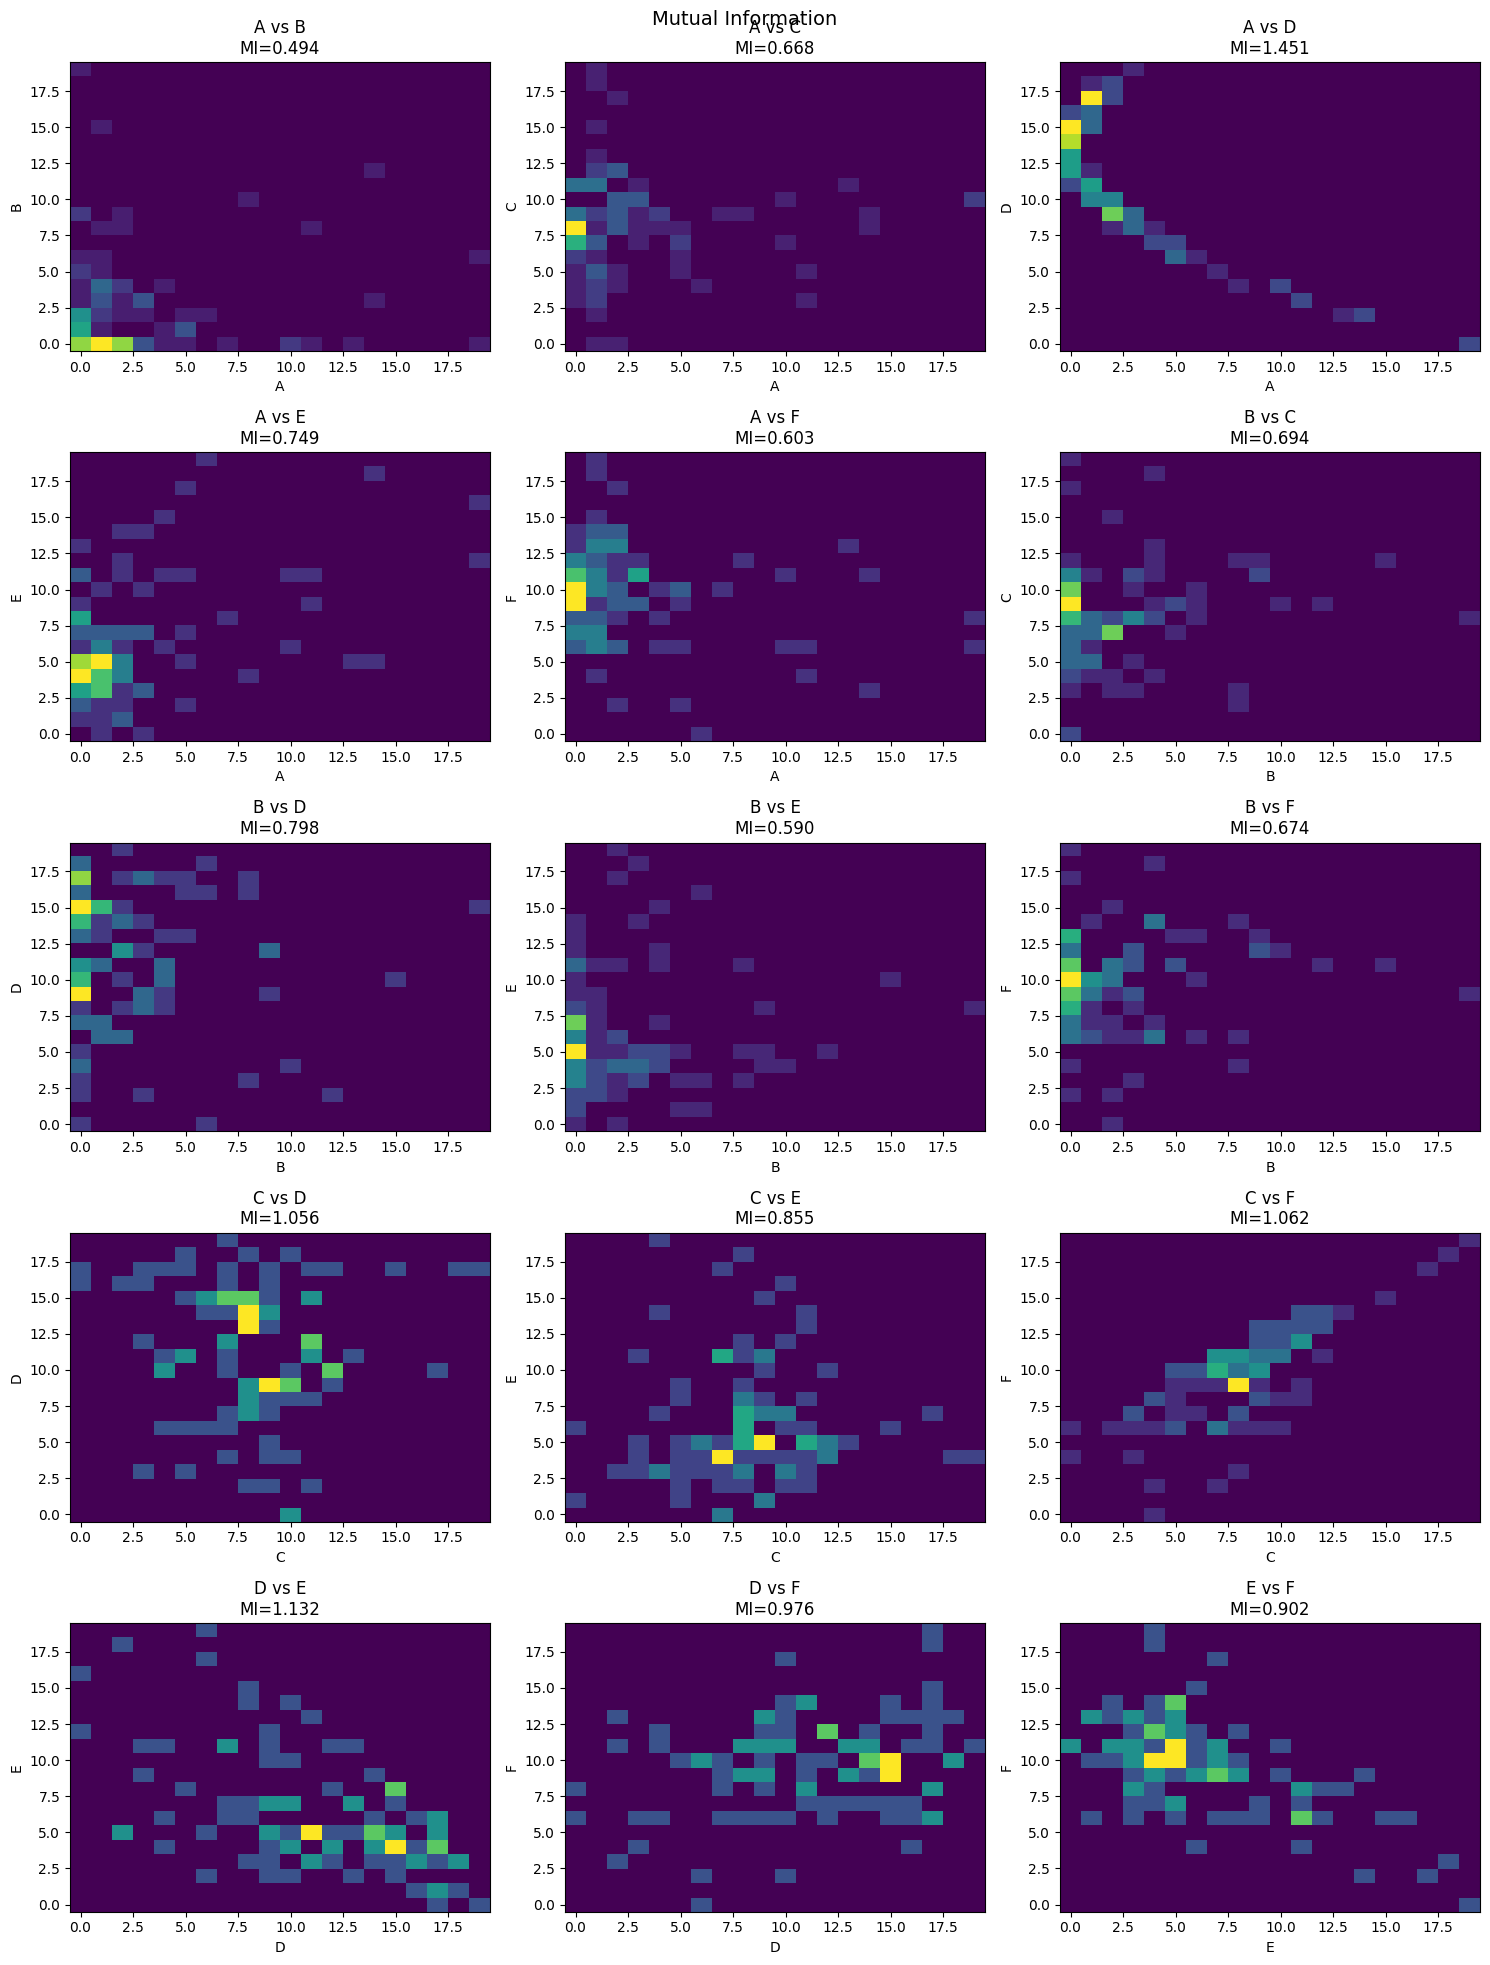

In [36]:
def MI(x, y, Nbins=21):
    bins_x = np.linspace(np.min(x), np.max(x), Nbins)
    bins_y = np.linspace(np.min(y), np.max(y), Nbins)
    eps = np.spacing(1)

    x_marginal = np.histogram(x, bins=bins_x)[0]
    x_marginal = x_marginal / x_marginal.sum()

    y_marginal = np.histogram(y, bins=bins_y)[0]
    y_marginal = y_marginal / y_marginal.sum()

    xy_joint = np.histogram2d(x, y, bins=(bins_x, bins_y))[0]
    xy_joint = xy_joint / xy_joint.sum()

    mi = np.sum(
        xy_joint * np.log(xy_joint / (x_marginal[:, None] * y_marginal[None, :] + eps) + eps)
    )
    return mi, xy_joint

# Lav alle MI-plots samlet i én stor figur

dftester = df#_int_nuld  # Vælg den DataFrame du vil teste på (fx df eller df_int_posc)

pairs = []
for i in range(len(dftester.columns)):
    for j in range(i + 1, len(dftester.columns)):
        pairs.append((dftester.columns[i], dftester.columns[j]))

n_pairs = len(pairs)
n_cols = 3
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for k, (col_x, col_y) in enumerate(pairs):
    x = dftester[col_x].values
    y = dftester[col_y].values
    mi_value, xy_joint = MI(x, y)

    ax = axes[k]
    im = ax.imshow(xy_joint.T, origin='lower', aspect='auto')
    ax.set_title(f"{col_x} vs {col_y}\nMI={mi_value:.3f}")
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)

    print(f"MI between {col_x} and {col_y}: {mi_value:.6f}")

# Skjul tomme akser hvis antallet af plots ikke fylder hele grid'et
for ax in axes[n_pairs:]:
    ax.axis('off')

fig.suptitle('Mutual Information', fontsize=14)
fig.tight_layout()
plt.show()

# MI values mean:
# 0.0 - 0.05: Ingen eller meget svag afhængighed
# 0.05 - 0.2: Svag afhængighed
# 0.2 - 0.5: Moderat afhængighed
# > 0.5: Stærk afhængighed

In [38]:
from pathlib import Path

# Kør MI kun for parret D og E 


data_dir = Path("..") / "data"
if not data_dir.exists():
    raise FileNotFoundError(f"Data-mappen blev ikke fundet: {data_dir}")

csv_files = sorted(data_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Ingen CSV-filer fundet i: {data_dir}")

results = []

for file_path in csv_files:
    df_file = pd.read_csv(file_path)

    if "D" not in df_file.columns or "E" not in df_file.columns:
        print(f"Springer {file_path.name} over: mangler kolonne D eller E")
        continue

    d_values = df_file["D"].dropna().to_numpy()
    e_values = df_file["E"].dropna().to_numpy()

    if len(d_values) < 2 or len(e_values) < 2:
        print(f"Springer {file_path.name} over: for få observationer i D eller E")
        continue

    if pd.Series(d_values).nunique() < 2 or pd.Series(e_values).nunique() < 2:
        print(f"Springer {file_path.name} over: D eller E er konstant")
        continue

    mi_value, xy_joint = MI(d_values, e_values)

    results.append((file_path.name, mi_value))
    print(f"MI between D and E in {file_path.name}: {mi_value:.6f}")


if results:
    results_df = pd.DataFrame(results, columns=["file", "mi_de"])
    display(results_df.sort_values("mi_de", ascending=False).reset_index(drop=True))


MI between D and E in -2a.csv: 0.800962
MI between D and E in -2b.csv: 1.479828
MI between D and E in -2f.csv: 1.774528
MI between D and E in 0b.csv: 0.875402
Springer 0d.csv over: D eller E er konstant
Springer 0ec.csv over: D eller E er konstant
MI between D and E in 2a.csv: 0.965789
MI between D and E in 2c.csv: 1.844295
Springer 2d.csv over: D eller E er konstant
Springer 2e.csv over: D eller E er konstant
MI between D and E in data_2358.csv: 1.132056


,file,mi_de
0,2c.csv,1.844295
1,-2f.csv,1.774528
2,-2b.csv,1.479828
3,data_2358.csv,1.132056
4,2a.csv,0.965789
5,0b.csv,0.875402
6,-2a.csv,0.800962


In [39]:
from pathlib import Path


def print_rows_per_file(data_dir):
    """Print number of rows for each CSV file in a data folder."""
    data_path = Path(data_dir)

    if not data_path.exists():
        raise FileNotFoundError(f"Data-mappen blev ikke fundet: {data_path}")

    csv_files = sorted(data_path.glob("*.csv"))
    if not csv_files:
        print(f"Ingen CSV-filer fundet i: {data_path}")
        return

    for file_path in csv_files:
        df_file = pd.read_csv(file_path)
        print(f"{file_path.name}: {len(df_file)} rows")


print_rows_per_file(Path("..") / "data")

-2a.csv: 100 rows
-2b.csv: 30 rows
-2f.csv: 30 rows
0b.csv: 100 rows
0d.csv: 100 rows
0ec.csv: 200 rows
2a.csv: 100 rows
2c.csv: 30 rows
2d.csv: 30 rows
2e.csv: 30 rows
data_2358.csv: 100 rows


In [23]:
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression


def icp_invariance_test(df, target_col, cause_col, confounder_cols=None, env_col=None, n_env=3, alpha=0.05):
    """
    Enkel invarians-test inspireret af Invariant Causal Prediction.

    Idé:
    - Del data op i miljøer (environments)
    - Fit en model for target ud fra kandidat-variabler
    - Test om residualerne er ens på tværs af miljøer

    Hvis residualerne ikke ser forskellige ud mellem miljøerne, er relationen mere stabil.
    """
    if confounder_cols is None:
        confounder_cols = [c for c in df.columns if c not in [target_col, cause_col, env_col]]

    cols = [target_col, cause_col] + confounder_cols
    if env_col is not None:
        cols.append(env_col)

    data = df[cols].dropna().copy()

    if env_col is None:
        # Skab kunstige miljøer ved at opdele cause_col i kvantiler
        data["environment"] = pd.qcut(data[cause_col], q=n_env, labels=False, duplicates="drop")
        env_col = "environment"

    X = data[[cause_col] + confounder_cols]
    y = data[target_col]
    env = data[env_col]

    model = LinearRegression()
    model.fit(X, y)
    residuals = y - model.predict(X)

    groups = [residuals[env == g] for g in sorted(env.unique())]
    groups = [g for g in groups if len(g) > 1]

    if len(groups) < 2:
        raise ValueError("Der skal være mindst to miljøer med mere end én observation hver.")

    stat, p_value = f_oneway(*groups)
    invariant = p_value > alpha

    return {
        "invariant": invariant,
        "p_value": p_value,
        "statistic": stat,
        "residual_model": model,
        "used_columns": cols,
    }


# Eksempel: brug første numeriske kolonne som kandidat-årsag og anden som target
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    cause_col = numeric_cols[0]
    target_col = numeric_cols[1]
    confounder_cols = [c for c in numeric_cols if c not in [cause_col, target_col]]

    icp_result = icp_invariance_test(df, target_col, cause_col, confounder_cols=confounder_cols)
    print(f"Cause candidate: {cause_col}")
    print(f"Target: {target_col}")
    print(f"Invariant relation: {icp_result['invariant']}")
    print(f"p-værdi: {icp_result['p_value']:.4f}")
else:
    print("Der skal være mindst to numeriske kolonner for at køre invarians-testen.")

Cause candidate: A
Target: B
Invariant relation: True
p-værdi: 0.5074


In [147]:
def kolmogorov_smirnov_test(df1, df2, var):
    from scipy.stats import ks_2samp
    stat, p = ks_2samp(df1[var], df2[var])
    print(f"Kolmogorov-Smirnov test for {var}: KS={stat:.4f}, p-value={p:.4f}")


kolmogorov_smirnov_test(df, df_int_nulb, var='A')



Kolmogorov-Smirnov test for A: KS=0.1500, p-value=0.2112


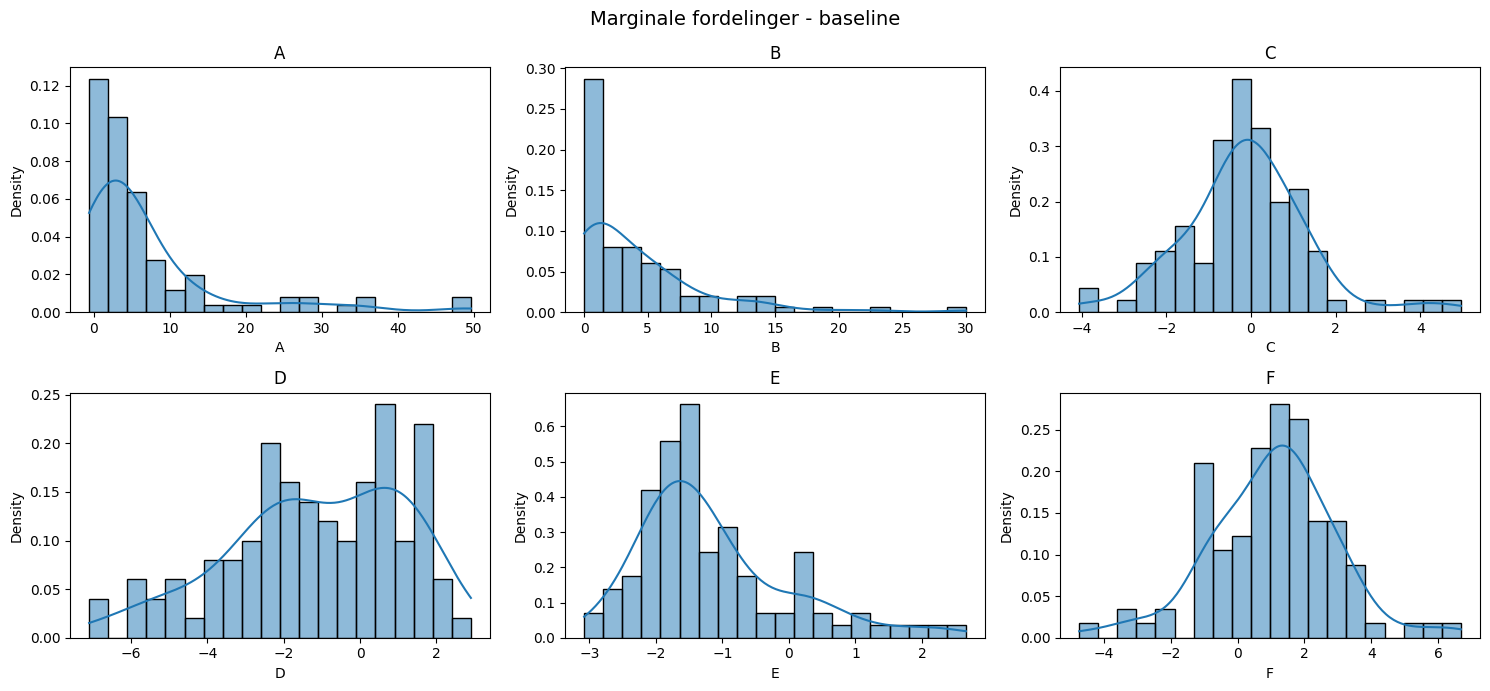

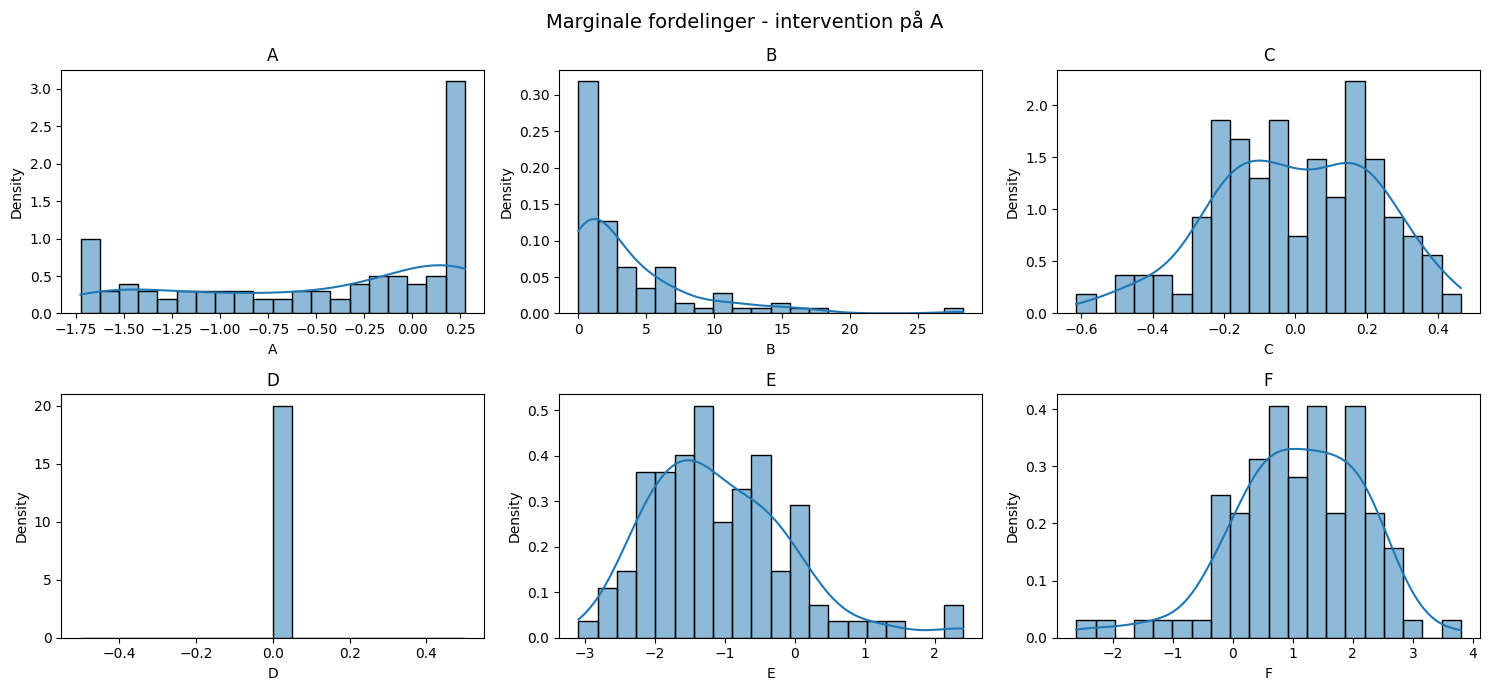

In [33]:
def plot_marginals(df, title):
    numeric_df = df.select_dtypes(include=np.number)
    columns = numeric_df.columns.tolist()
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, columns):
        sns.histplot(numeric_df[col], kde=True, stat='density', bins=20, ax=ax)
        ax.set_title(col)

    for ax in axes[len(columns):]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

plot_marginals(df, "Marginale fordelinger - baseline")
plot_marginals(df_int_nuld, "Marginale fordelinger - intervention på A")

# efter at have kigget på correlation, er marginalerne ofte mere informative for interventionen på A




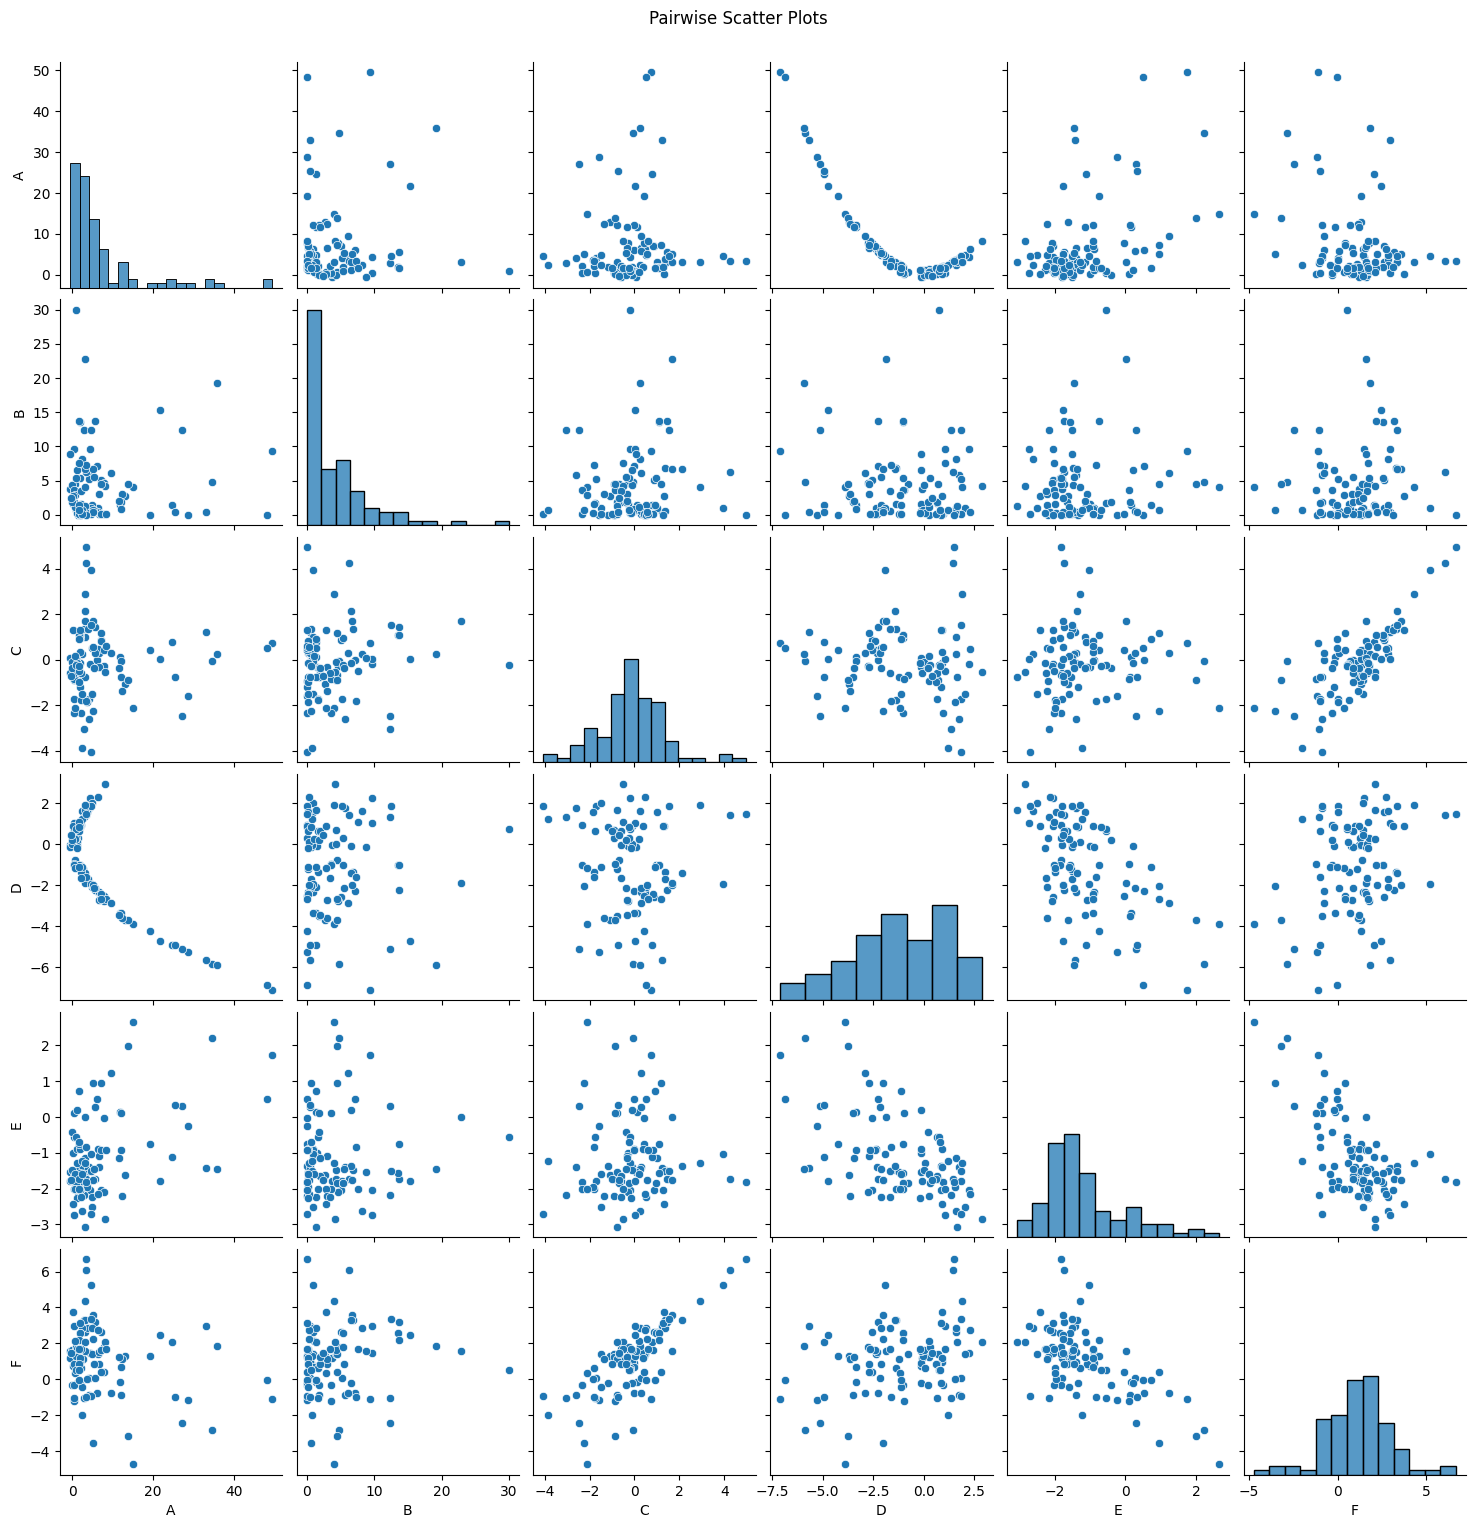

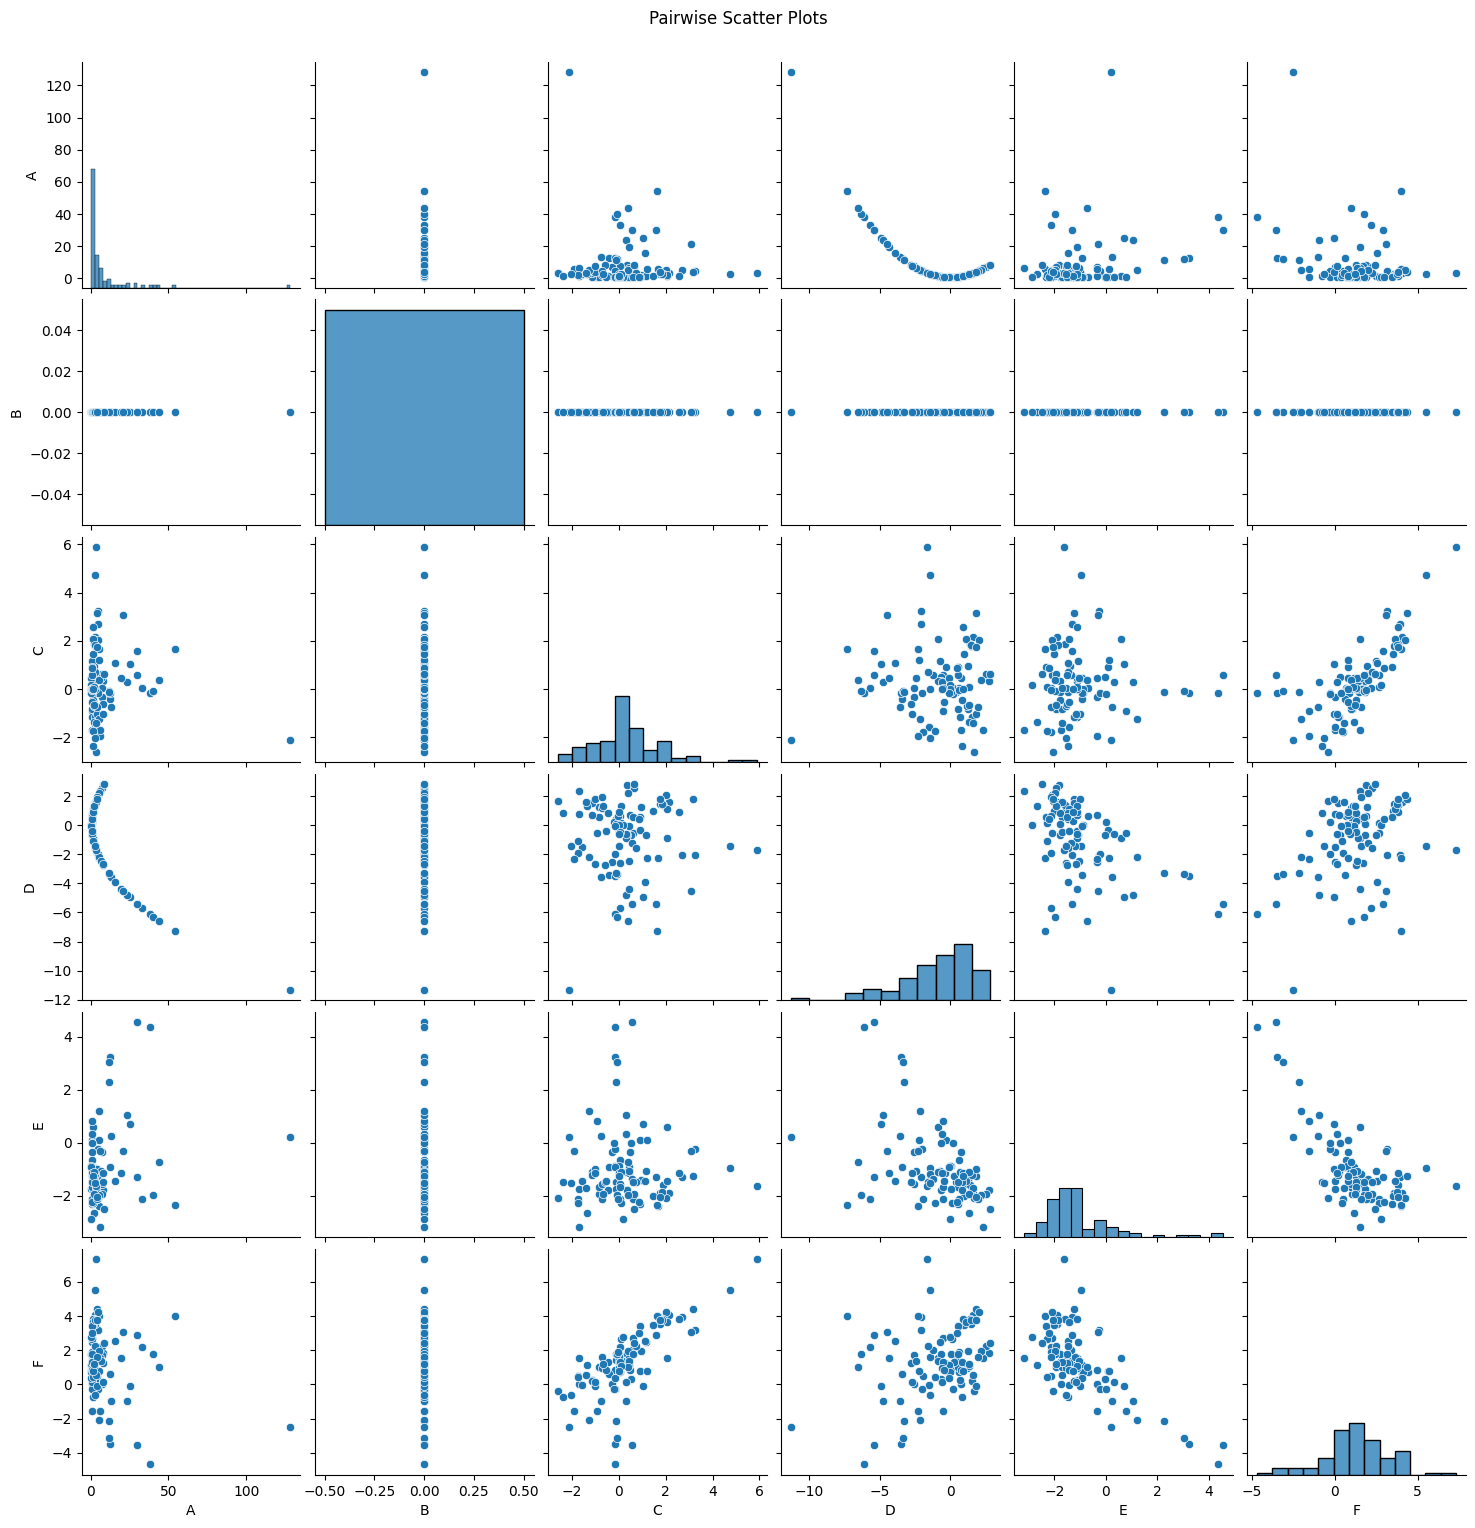

In [30]:
def pairwise_scatter(df):
    sns.pairplot(df)
    plt.suptitle("Pairwise Scatter Plots", y=1.02)
    plt.show()

pairwise_scatter(df)
pairwise_scatter(df_int_nulb)

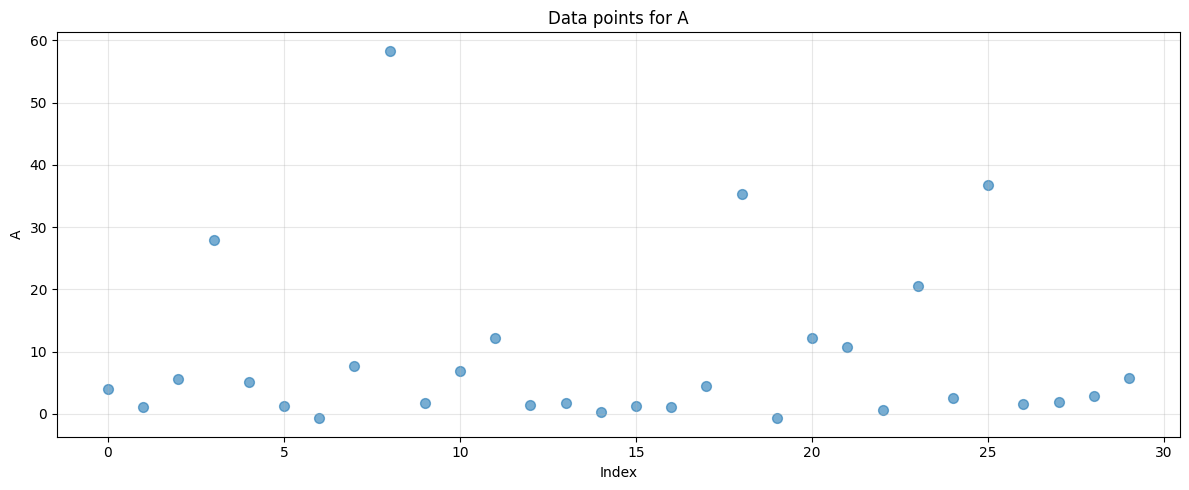

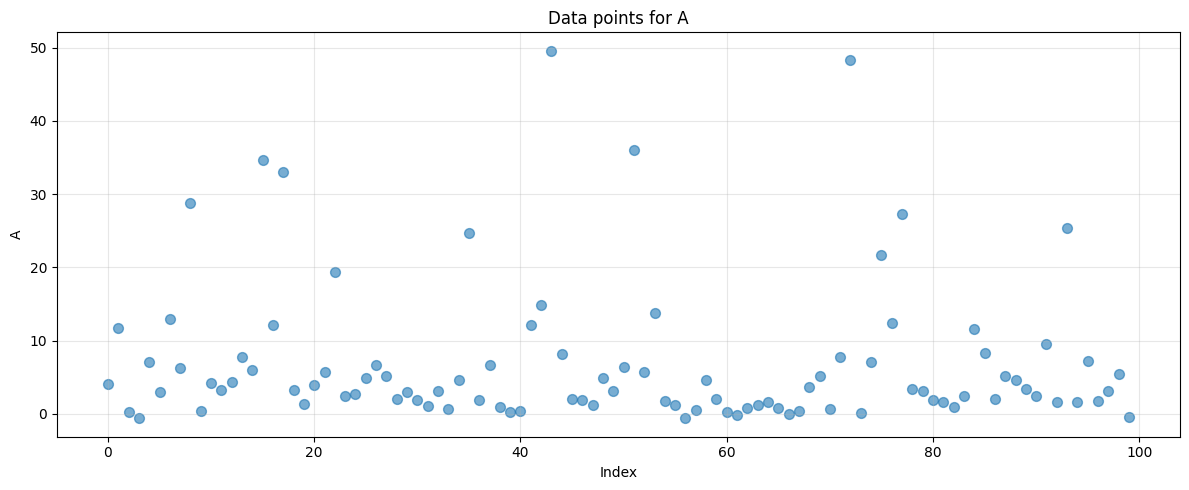

In [17]:
def plot_variable_points(df, variable, title=None):
    """
    Plot data points for a single variable in the dataframe.
    
    Parameters:
    df (pd.DataFrame): The dataframe
    variable (str): Column name to plot
    title (str): Optional title for the plot
    """
    if variable not in df.columns:
        print(f"Variable '{variable}' not found in dataframe columns")
        return
    
    plt.figure(figsize=(12, 5))
    
    # Scatter plot with index
    plt.scatter(range(len(df)), df[variable], alpha=0.6, s=50)
    plt.xlabel("Index")
    plt.ylabel(variable)
    plt.title(title or f"Data points for {variable}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Eksempel: plot variable 'A'
plot_variable_points(df_int_negf, 'A')
plot_variable_points(df, 'A')



In [27]:
def fit_line(df, x_col, y_col):
    from sklearn.linear_model import LinearRegression
    X = df[[x_col]].dropna()
    y = df[y_col].dropna()
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0], model.intercept_

for i in range(len(df.select_dtypes(include=np.number).columns)):
    for j in range(i + 1, len(df.select_dtypes(include=np.number).columns)):
        x_col = df.select_dtypes(include=np.number).columns[i]
        y_col = df.select_dtypes(include=np.number).columns[j]
        slope, intercept = fit_line(df, x_col, y_col)
        print(f"Line fit between {x_col} and {y_col}: slope={slope:.4f}, intercept={intercept:.4f}")



Line fit between A and B: slope=0.0389, intercept=3.8685
Line fit between A and C: slope=0.0048, intercept=-0.1637
Line fit between A and D: slope=-0.1833, intercept=0.1529
Line fit between A and E: slope=0.0522, intercept=-1.5147
Line fit between A and F: slope=-0.0465, intercept=1.3913
Line fit between B and C: slope=0.0318, intercept=-0.2621
Line fit between B and D: slope=-0.0231, intercept=-1.0328
Line fit between B and E: slope=0.0121, intercept=-1.2000
Line fit between B and F: slope=0.0255, intercept=0.9605
Line fit between C and D: slope=-0.1108, intercept=-1.1430
Line fit between C and E: slope=0.0102, intercept=-1.1485
Line fit between C and F: slope=0.9669, intercept=1.1921
Line fit between D and E: slope=-0.2768, intercept=-1.4623
Line fit between D and F: slope=0.2292, intercept=1.3248
Line fit between E and F: slope=-1.0273, intercept=-0.1150


Cosine fit between A and B: slope=-0.8863, intercept=4.2413
Cosine fit between A and C: slope=-0.1371, intercept=-0.1147
Cosine fit between A and D: slope=-0.4318, intercept=-1.0796
Cosine fit between A and E: slope=0.0337, intercept=-1.1537
Cosine fit between A and F: slope=-0.1669, intercept=1.0851
Cosine fit between B and C: slope=0.1892, intercept=-0.1890
Cosine fit between B and D: slope=0.1591, intercept=-1.1780
Cosine fit between B and E: slope=0.0288, intercept=-1.1588
Cosine fit between B and F: slope=0.1081, intercept=1.0326
Cosine fit between C and D: slope=-0.6087, intercept=-0.8449
Cosine fit between C and E: slope=0.0903, intercept=-1.1919
Cosine fit between C and F: slope=0.3629, intercept=0.8971
Cosine fit between D and E: slope=-0.1833, intercept=-1.1319
Cosine fit between D and F: slope=-0.0185, intercept=1.0680
Cosine fit between E and F: slope=-0.7842, intercept=1.1334


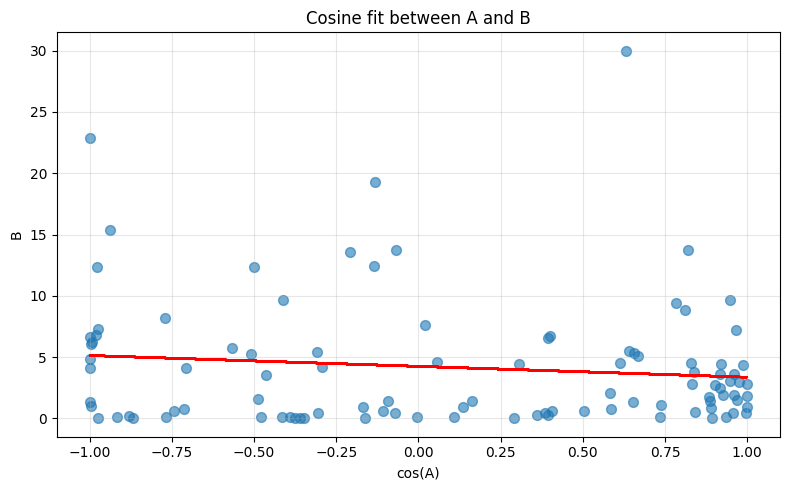

In [29]:
def fit_cosine(df, x_col, y_col):
    from sklearn.linear_model import LinearRegression
    X = np.cos(df[[x_col]].dropna())
    y = df[y_col].dropna()
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0], model.intercept_
for i in range(len(df.select_dtypes(include=np.number).columns)):
    for j in range(i + 1, len(df.select_dtypes(include=np.number).columns)):
        x_col = df.select_dtypes(include=np.number).columns[i]
        y_col = df.select_dtypes(include=np.number).columns[j]
        slope, intercept = fit_cosine(df, x_col, y_col)
        print(f"Cosine fit between {x_col} and {y_col}: slope={slope:.4f}, intercept={intercept:.4f}")

def plot_cosine_fit(df, x_col, y_col):
    from sklearn.linear_model import LinearRegression
    X = np.cos(df[[x_col]].dropna())
    y = df[y_col].dropna()
    model = LinearRegression()
    model.fit(X, y)
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, alpha=0.6, s=50)
    plt.plot(X, model.predict(X), color='red')
    plt.xlabel(f"cos({x_col})")
    plt.ylabel(y_col)
    plt.title(f"Cosine fit between {x_col} and {y_col}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_cosine_fit(df, 'A', 'B')